In [1]:
# 各电站多日现货汇总复盘【基于生成的各站各日日清分复盘单】

##### 1.选择需要复盘的场站
##### 2.选择需要选取的日期区间
##### 3.遍历读取所选站的日复盘单sheet3，提取中长期合约，中长期电费，日前结算电量，日前结算电费，日前出清电量，日前出清电价，实时结算电量，实时结算电费，实时出清电量，实时出清电价
##### 4.计算sigma(中长期合约)，sigma（中长期电费），sigma(日前结算电量),sigma(日前结算电费)，sigma(日前出清电量)，sigma(实时结算电量)，sigma(实时结算电费)，sigma（实时出清电量），sigma(实时出清电价)
##### 5.计算ave(中长期电价)=sigma（中长期电费）/sigma(中长期合约)，ave(日前电价)=sigma(日前结算电费)/sigma(日前结算电量)，ave(实时电价)=sigma(实时结算电费)/sigma(实时结算电量)，
##### 6.至此所有元素统计完毕，计算汇总后的日前-中长期量差、价差，从而计算盈亏。
##### 7.【画图】日汇总图（1*24）（中长期电量、日前结算电量堆叠图；中长期电价、日前电价折线图；价差汇总柱状图；量差汇总柱状图；盈亏分析柱状图）、各日价差汇总图（天数*24）（热图）、各日量差汇总图（天数*24）（热图）、各日盈亏汇总图（天数*24）（热图）
##### 实时vs日前同理
##### 8.计算中长期、现货电价（1*天数）；
##### 9.【画图】中长期、现货电价走势（1*天数）；盈亏走势（1*天数）
##### 实时vs日前同理

In [16]:
import pandas as pd
import glob
import os
from datetime import datetime

In [81]:
# 输入参数
folder_path = "D:/工作/特变电工/01_0政策与学习笔记/_全国_20250520/国网区域/新疆/400-交易复盘/现货日复盘/"  # 替换为文件夹路径
station_name_List = ["哈密十三间房新特风能有限责任公司（新特森泽风电一场）","哈密市振超风力发电有限公司（振超分散式兴业风电一场）","莎车县新尚能源发电有限责任公司（新尚能源莎车光伏一电站）","柯坪县柯特新能源有限责任公司（柯特新能源柯坪光伏一电站）","若羌县卓尚新能源有限公司（卓尚若羌风电一场）"]  # 替换为指定的电站名称
start_date = '2025-06-13'  # 选择开始日期
end_date = '2025-06-22'    # 选择结束日期
output_path="D:/工作/特变电工/01_0政策与学习笔记/_全国_20250520/国网区域/新疆/400-交易复盘/现货日复盘_按日汇总/"

✅2025-06-13至2025-06-22_哈密十三间房新特风能有限责任公司（新特森泽风电一场）多日复盘分析单已生成🚀
📈哈密十三间房新特风能有限责任公司（新特森泽风电一场）2025-06-13至2025-06-22中长期vs日前交易情况.png生成中...


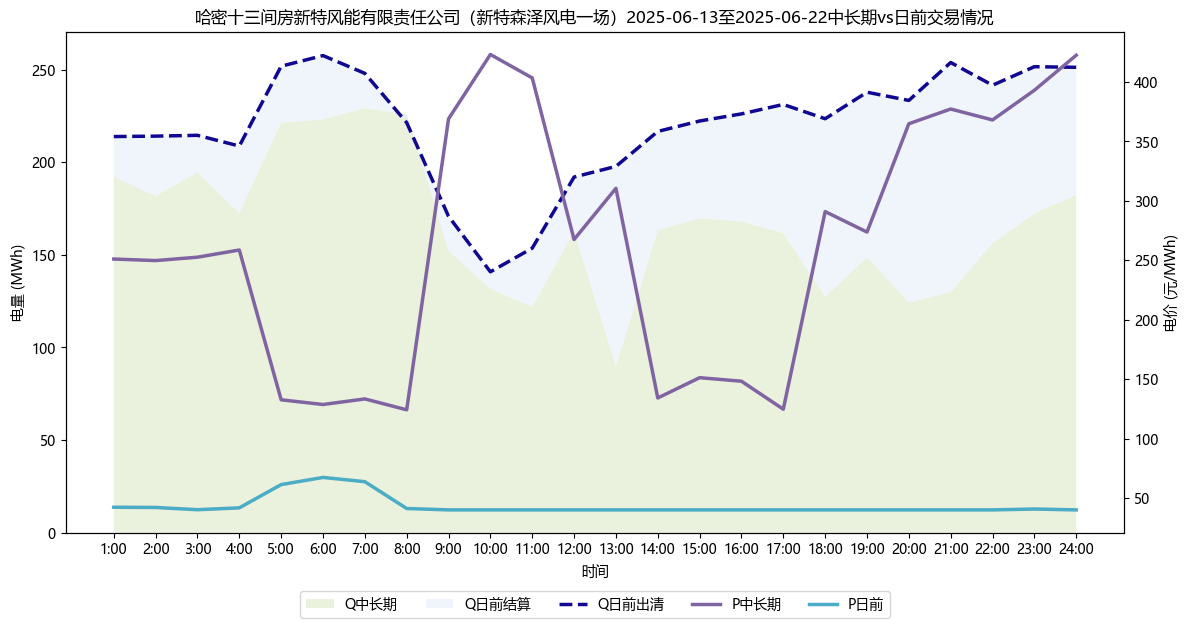

✅2025-06-13至2025-06-22_哈密市振超风力发电有限公司（振超分散式兴业风电一场）多日复盘分析单已生成🚀
📈哈密市振超风力发电有限公司（振超分散式兴业风电一场）2025-06-13至2025-06-22中长期vs日前交易情况.png生成中...


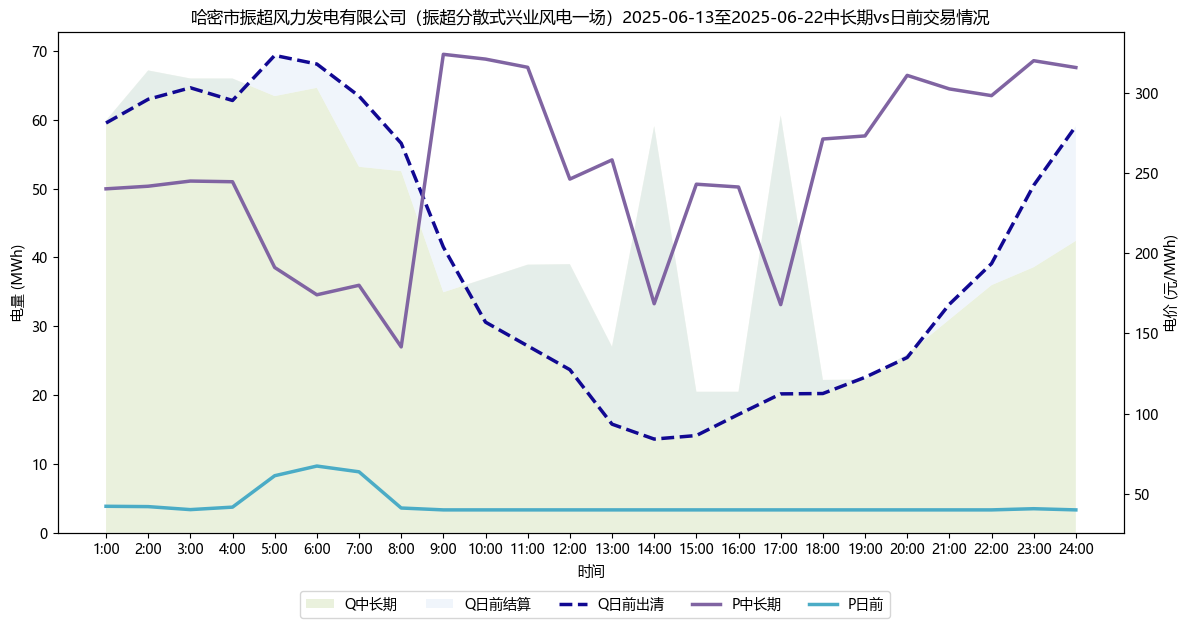

✅2025-06-13至2025-06-22_莎车县新尚能源发电有限责任公司（新尚能源莎车光伏一电站）多日复盘分析单已生成🚀
📈莎车县新尚能源发电有限责任公司（新尚能源莎车光伏一电站）2025-06-13至2025-06-22中长期vs日前交易情况.png生成中...


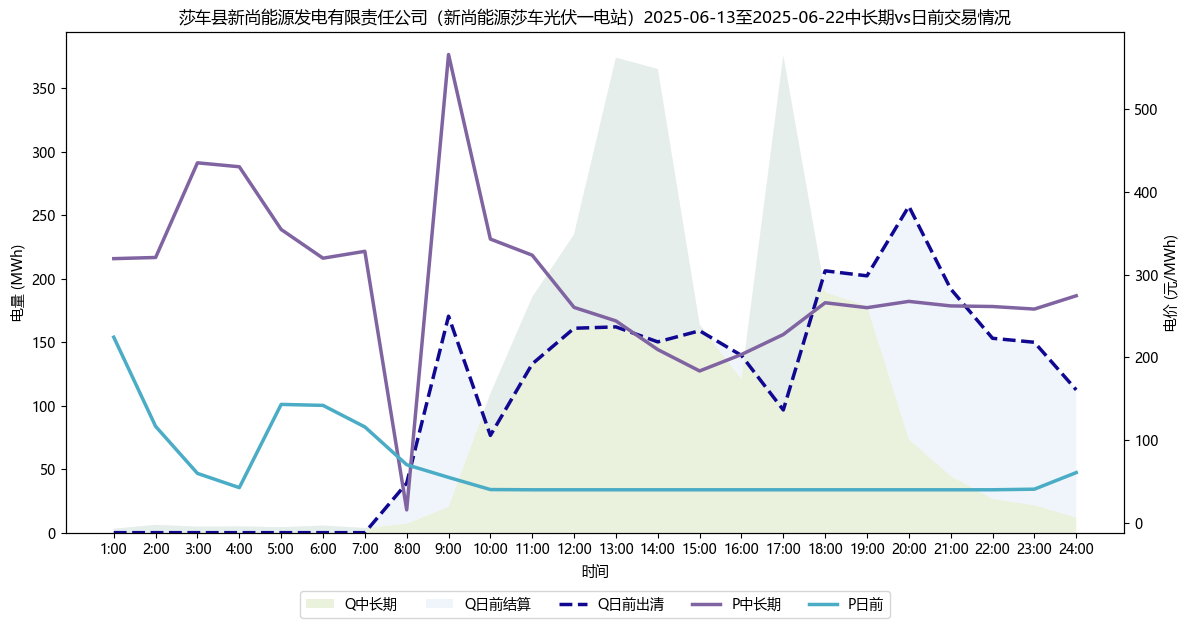

✅2025-06-13至2025-06-22_柯坪县柯特新能源有限责任公司（柯特新能源柯坪光伏一电站）多日复盘分析单已生成🚀
📈柯坪县柯特新能源有限责任公司（柯特新能源柯坪光伏一电站）2025-06-13至2025-06-22中长期vs日前交易情况.png生成中...


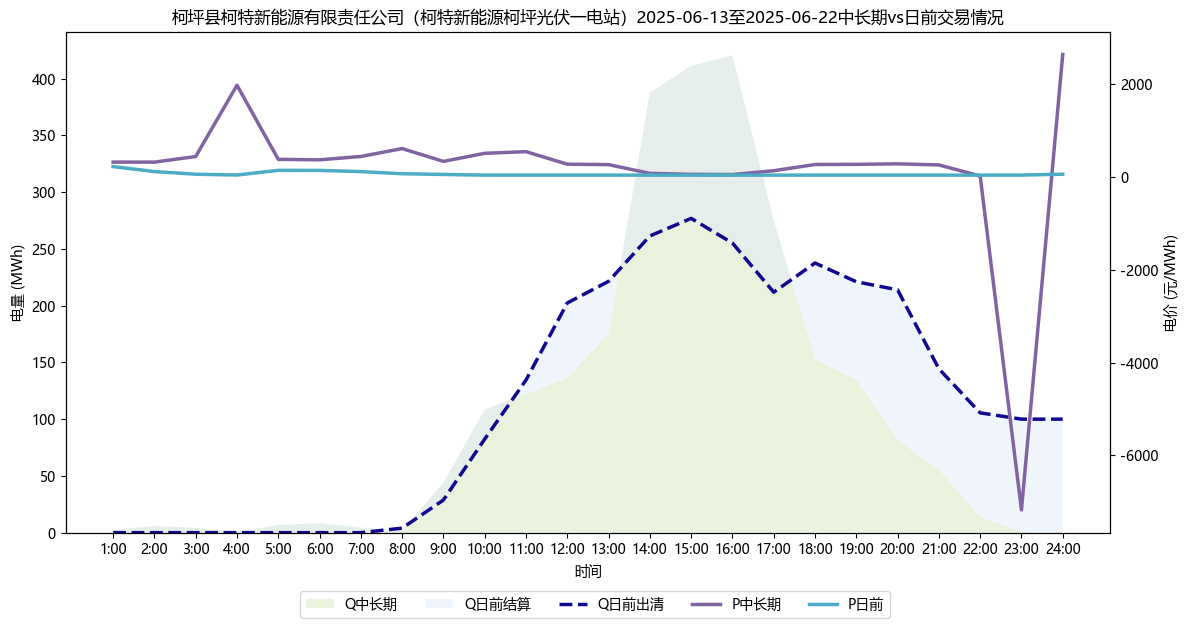

✅2025-06-13至2025-06-22_若羌县卓尚新能源有限公司（卓尚若羌风电一场）多日复盘分析单已生成🚀
📈若羌县卓尚新能源有限公司（卓尚若羌风电一场）2025-06-13至2025-06-22中长期vs日前交易情况.png生成中...


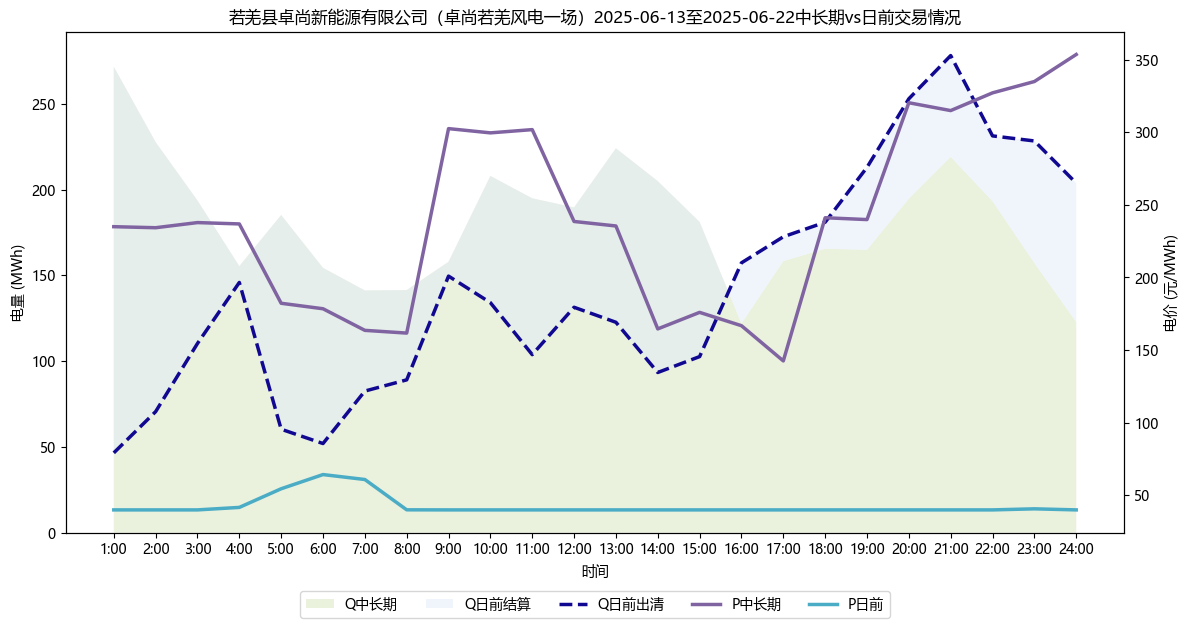

In [95]:
# 汇总list
df_list = []
for station_name in station_name_List:
    df_result=df_process_main(station_name,start_date,end_date,folder_path,output_path)
    plotDayAheadvsMidLongReview(station_name,start_date,end_date,df_result,output_path)
    df_list.append(df_result)  
# 使用 pd.concat() 合并所有 DataFrame
df_result_combined = pd.concat(df_list, ignore_index=True)

In [50]:
# 【成分提取及导出exel模块_main】
def df_process_main(station_name,start_date,end_date,folder_path,output_path):
     #获取汇总数据
    summary_data = gather_excel_files(station_name, start_date, end_date, folder_path)
    # print(summary_data)
    _1sum_filtered_MidLongContr_df=ContractQuantorRevSum("中长期电量汇总",summary_data)
    _2sum_filtered_MidLongRev_df=ContractQuantorRevSum("中长期电费汇总",summary_data)
    _3sum_filtered_dayAheadSettlementContr_df=ContractQuantorRevSum("现货日前结算电量",summary_data)
    _4sum_filtered_dayAheadClearContr_df=ContractQuantorRevSum("现货日前出清电量",summary_data)
    _5sum_filtered_dayAheadSettlementRev_df=ContractQuantorRevSum("现货日前结算电费",summary_data)
    _6sum_filtered_realtimeSettlementContr_df=ContractQuantorRevSum("现货实时结算电量",summary_data)
    _7sum_filtered_realtimeClearContr_df=ContractQuantorRevSum("现货实时出清电量",summary_data)
    _8sum_filtered_realtimeSettlementRev_df=ContractQuantorRevSum("现货实时结算电费",summary_data)
    df_contact_QuantRev=pd.concat([_1sum_filtered_MidLongContr_df, _2sum_filtered_MidLongRev_df, _3sum_filtered_dayAheadSettlementContr_df,
                          _4sum_filtered_dayAheadClearContr_df,_5sum_filtered_dayAheadSettlementRev_df,_6sum_filtered_realtimeSettlementContr_df,
                          _7sum_filtered_realtimeClearContr_df,_8sum_filtered_realtimeSettlementRev_df], ignore_index=True)
    #【中长期合约电价、现货日前出清电价、现货实时出清电价】
    _9ave_filtered_MidLongPrice_df=midLongPrice(_1sum_filtered_MidLongContr_df,_2sum_filtered_MidLongRev_df)
    _10ave_filtered_dayAheadPrice_df=SpotPriceAve("现货日前出清电价",summary_data)
    _11ave_filtered_realtimePrice_df=SpotPriceAve("现货实时出清电价",summary_data)
    # 【特殊机制合计】
    sum_frRev=ContractQuantorRevSum("调频辅助服务里程收益",summary_data)
    sum_fr_allocation_Cost=ContractQuantorRevSum("调频辅助服务费用分摊",summary_data)
    sum_unitPenaltyCostRecovery=ContractQuantorRevSum("机组考核费用-回收",summary_data)
    sum_unitPenaltyCostAllocation=ContractQuantorRevSum("机组考核费用-分摊",summary_data)
    sum_GenMidLongRecovery=ContractQuantorRevSum("发电侧中长期偏差收益回收-回收",summary_data)
    sum_GenMidLongAllocation=ContractQuantorRevSum("发电侧中长期偏差收益回收-分摊",summary_data)
    sum_ConsumerMidLongAllocation=ContractQuantorRevSum("用户侧中长期偏差收益回收-分摊",summary_data)
    sum_ConsumerSpotAllocation=ContractQuantorRevSum("用户侧现货偏差收益回收-分摊",summary_data)
    special_concat=pd.concat([sum_frRev,sum_fr_allocation_Cost,sum_unitPenaltyCostRecovery,sum_unitPenaltyCostAllocation,
                              sum_GenMidLongRecovery,sum_GenMidLongAllocation,sum_ConsumerMidLongAllocation,sum_ConsumerSpotAllocation], ignore_index=True)
    df_contact_final=pd.concat([df_contact_QuantRev,_9ave_filtered_MidLongPrice_df,_10ave_filtered_dayAheadPrice_df,_11ave_filtered_realtimePrice_df,
                           special_concat ], ignore_index=True)
    df_contact_final.insert(0,'场站名称',station_name)
    df_contact_final.insert(1,'日期区间',f"{start_date}至{end_date}")
    df_contact_final.rename(columns={df_contact_final.columns[2]: '名称'}, inplace=True)
    # 保存 DataFrame 到 Excel 文件
    output_file = f"{output_path}{station_name}{start_date}至{end_date}日清分复盘汇总.xlsx"  # 指定输出文件名
    # 保存 DataFrame 到 Excel 文件
    # 使用 ExcelWriter 保存多个工作表
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        summary_data.to_excel(writer, index=False, sheet_name='Sheet1')
        df_contact_final.to_excel(writer, index=False, sheet_name='Sheet2')
        print(f"✅{start_date}至{end_date}_{station_name}多日复盘分析单已生成🚀")
    return df_contact_final

In [11]:
# 【指定电站、日期区间日清分复盘单汇总】
def gather_excel_files(station_name, start_date, end_date, folder_path):
    # 转换日期字符串为日期对象
    start_date = datetime.strptime(start_date, '%Y-%m-%d')
    end_date = datetime.strptime(end_date, '%Y-%m-%d')

    # 获取符合条件的文件路径[files类型为list]
    pattern = os.path.join(folder_path, f'*_{station_name}_日复盘.xlsx')
    files = glob.glob(pattern)  

    # 初始化一个空的DataFrame以汇总数据
    all_data = pd.DataFrame()

    for file in files:
        # 提取文件名中的日期部分
        file_name = os.path.basename(file)
        date_str = file_name.split('_')[0]  # 获取日期部分
        file_date = datetime.strptime(date_str, '%Y-%m-%d')

        # 检查日期是否在范围内
        if start_date <= file_date <= end_date:
            # 读取Excel文件
            data = pd.read_excel(file, sheet_name='日复盘Type1')  # 根据需要调整sheet名称
            
            # 添加场站名称和日期列
            data.insert(0, '场站名称', station_name)
            data.insert(1, '日期', file_date)
            
            # 将当前数据与汇总数据合并
            all_data = pd.concat([all_data, data], ignore_index=True)

    return all_data

In [12]:
# 成分抽取求和，按照科目名称进行求和
def ContractQuantorRevSum(item_str,df):
    # item_str为需要提取汇总的科目名称
    filtered_df=df[df["名称"].isin([item_str])]
    series=filtered_df.iloc[:,3:].reset_index(drop=True).sum(axis=0)
    series.name=item_str
    df_processed=series.to_frame().T
    df_processed=df_processed.reset_index()
    return df_processed

In [13]:
# 现货电价求平均
def SpotPriceAve(item_str,df):
    # item_str为需要提取汇总的科目名称
    filtered_df=df[df["名称"].isin([item_str])]
    series=filtered_df.iloc[:,3:].reset_index(drop=True).mean(axis=0)
    series.name=item_str
    df_processed=series.to_frame().T
    df_processed=df_processed.reset_index()
    return df_processed

In [14]:
# 中长期电价求平均
def midLongPrice(quant_df,rev_df):
    # quant_df中长期合约电量（带索引列）
    #rev_df中长期合约电费（带索引列）
    quant_df=quant_df.drop(columns='index').astype(float)
    rev_df=rev_df.drop(columns='index').astype(float)
    ave_price=rev_df/quant_df
    ave_price.insert(0,'index','中长期合约电价')
    return ave_price    

In [94]:
# 画图函数1-日前vs中长期
def plotDayAheadvsMidLongReview(name,start_date,end_date,df_contact_final,output_path):
    import pandas as pd
    import matplotlib.pyplot as plt
    from io import StringIO
    import matplotlib
    # 设置 Windows 中文字体
    matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei']  
    matplotlib.rcParams['axes.unicode_minus'] = False  
    # ==== 数据 ====
    period=f"{start_date}至{end_date}"
    # data = """名称	1:00	2:00	3:00	4:00	5:00	6:00	7:00	8:00	9:00	10:00	11:00	12:00	13:00	14:00	15:00	16:00	17:00	18:00	19:00	20:00	21:00	22:00	23:00	24:00
    # 中长期电量汇总	59.886	67.165	65.997	65.993	63.443	64.644	53.17	52.536	34.94	36.939	38.939	39.01	27.011	59.082	20.474	20.475	60.625	22.194	22.25	25.94	30.97	35.969	38.58	42.41
    # 现货日前出清电量	59.531	62.978	64.652	62.803	69.354	68.101	63.441	56.588	41.503	30.592	27.14	23.683	15.768	13.6	14.115	17.186	20.168	20.219	22.573	25.453	33.191	39.098	50.47	59.076
    # 中长期合约电价	240.0584444	241.6891238	244.9062836	244.4775961	191.0508646	174.0328569	179.957871	141.5642607	323.8752147	320.8995912	315.7803231	246.1266342	258.0852245	168.4621374	242.9461756	241.1921856	167.8957526	271.1052537	273.0292135	310.7632999	302.3216015	298.1292224	319.8976153	315.6413582
    # 现货日前出清电价	42.246	42.039	40.169	41.718	61.287	67.315	63.725	41.169	40	40	40	40	40	40	40	40	40	40	40	40	40	40	40.733	40
    # """
    df_contact_temp=df_contact_final.iloc[0:11,2:-1]
    rows_to_pick = [0, 3, 8, 9] 
    df_t=df_contact_temp.iloc[rows_to_pick].reset_index(drop=True)
    #转置方便绘图
    df_t = df_t.set_index("名称").T
    plot_columns=['Q中长期','Q日前出清','P中长期','P日前']
    df_t.columns=plot_columns
    for col in plot_columns:
        df_t[col] = pd.to_numeric(df_t[col], errors='coerce')  
    hours = df_t.index

    # 创建图表
    fig, ax1 = plt.subplots(figsize=(12, 6))
    # 面积堆叠图（电量）
    ax1.stackplot(hours,
                  df_t["Q中长期"],
                  df_t["Q日前出清"]-df_t["Q中长期"],
                   colors=["#d7e4bd", "#e2ecf8"],  # 天蓝 + 浅绿
                  labels=["Q中长期","Q日前结算" ],
                  alpha=0.5)
    ax1.plot(hours, df_t["Q日前出清"],  label="Q日前出清",linewidth=2.5, color="#110892" , linestyle="--")
    ax1.set_ylabel("电量 (MWh)")
    ax1.set_xlabel("时间")
    # ax1.legend(loc="upper left")
    
    # 第二y轴绘制折线图（电价）
    ax2 = ax1.twinx()
    ax2.plot(hours, df_t["P中长期"], label="P中长期",  color="#8064a2",linewidth=2.5)
    ax2.plot(hours, df_t["P日前"], label="P日前", color="#4bacc6",linewidth=2.5)
    ax2.set_ylabel("电价 (元/MWh)")
    # ax2.legend(loc="upper right")
    # 添加全局图例
    fig.legend(loc='lower center',bbox_to_anchor=(0.5, -0.05), ncol=5)  # ncol=2 表示横向排列

    plt.title(f"{name}{period}中长期vs日前交易情况")
    plt.xticks(rotation=45)
    plt.tight_layout()
    print(f"📈{name}{period}中长期vs日前交易情况.png生成中...")
    plt.savefig(f"{output_path}{name}{period}中长期vs日前交易情况.png", format='png', dpi=300)  # 保存为 PNG 格式
    plt.show()
    plt.close() 

    return df_t